<Axes: title={'center': '13C NMR Spectra'}, xlabel='Chemical Shift (ppm)'>

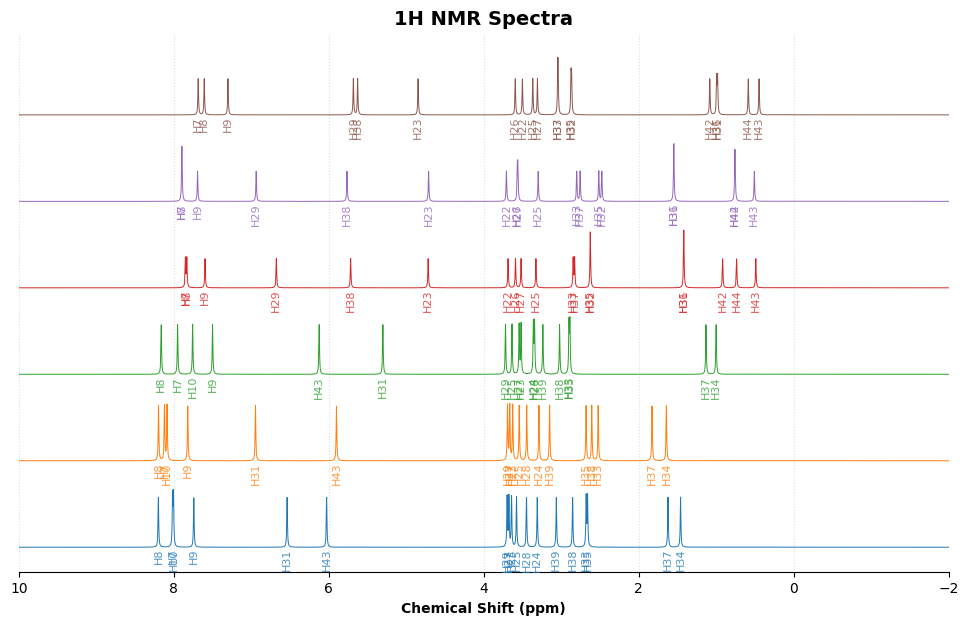

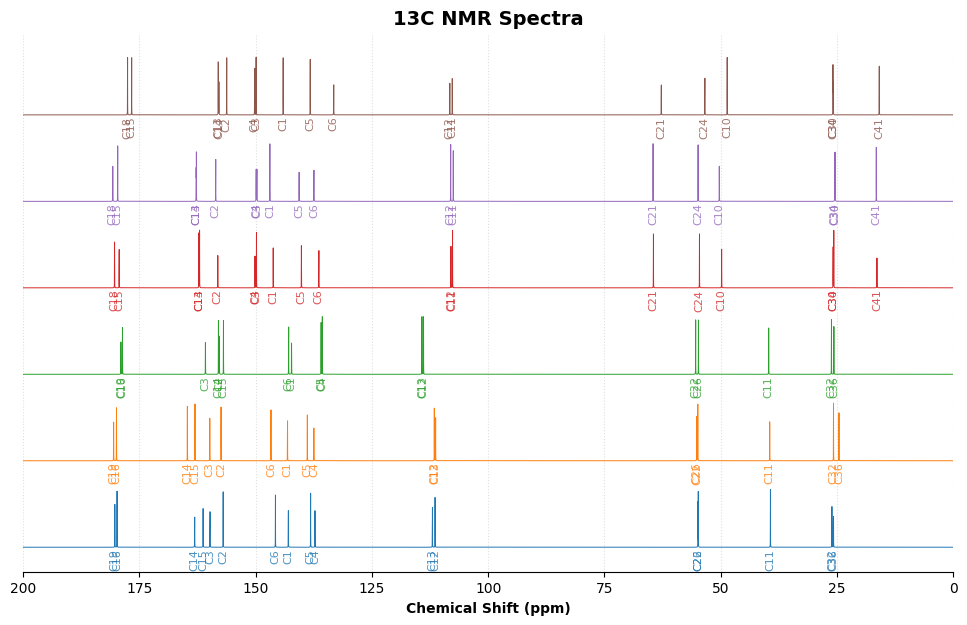

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import re

def plot_orca_nmr(file_input, default_tms=None, nucleus='1H', fwhm=None, 
                  offset=1.3, export_csv=False, x_range=None, linewidth=1.5,
                  label_rotation=90, label_voffset=0.02):
    
    target_element = re.sub(r'\d+', '', nucleus)
    if fwhm is None:
        fwhm = 0.05 if target_element == 'H' else 1.0

    def extract_nmr_summary(filepath):
        if not filepath or not os.path.exists(filepath): return None
        data = []
        with open(filepath, 'r') as f:
            lines = f.readlines()
        start_idx = -1
        for i, line in enumerate(reversed(lines)):
            if "CHEMICAL SHIELDING SUMMARY (ppm)" in line:
                start_idx = len(lines) - i
                break
        if start_idx == -1: return None
        pattern = re.compile(r"^\s*(\d+)\s+([A-Za-z]+)\s+(-?\d+\.\d+)")
        for line in lines[start_idx:]:
            if "---" in line or "Nucleus" in line: continue
            if not line.strip(): 
                if data: break 
                else: continue
            match = pattern.search(line)
            if match:
                data.append({'Atom': int(match.group(1)) + 1, 'Element': match.group(2), 'Isotropic': float(match.group(3))})
            elif data: break
        return pd.DataFrame(data) if data else None

    if x_range is None:
        x_min, x_max = (-1, 12) if target_element == 'H' else (-10, 220)
    else:
        x_min, x_max = sorted(x_range)

    x_axis = np.linspace(x_min, x_max, 10000)
    fig, ax = plt.subplots(figsize=(12, 7))

    file_dict = file_input if isinstance(file_input, dict) else {f: os.path.splitext(os.path.basename(f))[0] for f in file_input}

    for i, (path, config) in enumerate(file_dict.items()):
        label = config.get('label', path) if isinstance(config, dict) else config
        tms_path = config.get('tms', default_tms) if isinstance(config, dict) else default_tms
        tms_df = extract_nmr_summary(tms_path)
        if tms_df is None: continue
        sigma_ref = tms_df[tms_df['Element'] == target_element]['Isotropic'].mean()
        mol_df = extract_nmr_summary(path)
        if mol_df is None: continue
        nucleus_df = mol_df[mol_df['Element'] == target_element].copy()
        nucleus_df['Shift'] = sigma_ref - nucleus_df['Isotropic']
        
        y_curve = np.zeros_like(x_axis)
        gamma_sq, pre = (0.5 * fwhm)**2, (0.5 * fwhm) / np.pi
        for s in nucleus_df['Shift']:
            y_curve += pre / ((x_axis - s)**2 + gamma_sq)
        
        if np.max(y_curve) > 0:
            y_norm = y_curve / np.max(y_curve)
            line, = ax.plot(x_axis, y_norm + (i * offset), label=label, lw=linewidth)
            for _, row in nucleus_df.iterrows():
                if x_min <= row['Shift'] <= x_max:
                    ax.text(row['Shift'], (i * offset) - label_voffset, f"{row['Element']}{row['Atom']}", 
                             ha='center', va='top', rotation=label_rotation, 
                             fontsize=8, color=line.get_color(), alpha=0.8)

    ax.set_title(f"{nucleus} NMR Spectra", fontsize=14, fontweight='bold')
    ax.set_xlabel("Chemical Shift (ppm)", fontweight='bold')
    ax.set_xlim(x_max, x_min)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.set_yticks([])
    ax.grid(axis='x', linestyle=':', alpha=0.4)
    
    return ax # Returning the handle

def add_experimental_nmr(ax, filepath, label='Experimental', offset=0.0, 
                         color='black', linewidth=0.8, scale=1.0, x_shift=0.0):
    """
    Adds experimental data to the axis with manual control over:
    - offset: Vertical stacking position
    - scale: Vertical height of peaks
    - x_shift: Horizontal alignment (ppm)
    """
    if not os.path.exists(filepath):
        print(f"File {filepath} not found.")
        return ax

    df = pd.read_csv(filepath, sep='\t')
    
    # Baseline correction and normalization (0 to 1)
    y_raw = df['y'].values
    y_norm = (y_raw - np.min(y_raw)) / (np.max(y_raw) - np.min(y_raw))
    
    # Apply x_shift to the ppm column
    x_corrected = df['x'].values + x_shift
    
    # Plot with user parameters
    ax.plot(x_corrected, (y_norm * scale) + offset, 
            label=label, color=color, lw=linewidth)
    
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper right')
    return ax

# Define individual files with specific TMS references
nmr_data = {
    "./Nifedipine_NMR/Nifedipine_GlobalMin_NMR_CDCl3_ChemShifts_PBE0_pcSseg-2_RIJCOSX.out": {
        "label": "Nif (CDCl3)", 
        "tms": "./TMS_NMR/TMS_CDCl3_PBE0_pcSseg-2_RIJCOSX_NMR.out"
    },
    "./Nifedipine_NMR/Nifedipine_GlobalMin_NMR_DMSO_ChemShifts_PBE0_pcSseg-2_RIJCOSX.out": {
        "label": "Nif (DMSO)", 
        "tms": "./TMS_NMR/TMS_DMSO_PBE0_pcSseg-2_RIJCOSX_NMR.out"
    },
    "./Nifedipine_NMR/Nifedipine_GlobalMin_NMR_GasPhase_ChemShifts_PBE0_pcSseg-2_RIJCOSX.out": {
        "label": "Nif (Gas Phase)", 
        "tms": "./TMS_NMR/TMS_GasPhase_PBE0_pcSseg-2_RIJCOSX_NMR.out"
    },
    "./Felodipine_NMR/Felodipine_GlobalMin_NMR_SMD_CDCl3_ChemShifts_PBE0_pcSseg-2_RIJCOSX.out": {
        "label": "Fel (CDCl3)", 
        "tms": "./TMS_NMR/TMS_CDCl3_PBE0_pcSseg-2_RIJCOSX_NMR.out"
    }
    ,
    "./Felodipine_NMR/Felodipine_GlobalMin_NMR_SMD_DMSO_ChemShifts_PBE0_pcSseg-2_RIJCOSX.out": {
        "label": "Fel (DMSO)", 
        "tms": "./TMS_NMR/TMS_DMSO_PBE0_pcSseg-2_RIJCOSX_NMR.out"
    },
    "./Felodipine_NMR/Felodipine_GlobalMin_NMR_GasPhase_ChemShifts_PBE0_pcSseg-2_RIJCOSX.out": {
        "label": "Fel (Gas Phase)", 
        "tms": "./TMS_NMR/TMS_GasPhase_PBE0_pcSseg-2_RIJCOSX_NMR.out"
    }
}

plot_orca_nmr(
    file_input=nmr_data, 
    nucleus='1H', 
    fwhm=0.01,        # Sharp lines
    offset=1.5,       # Vertical spacing
    linewidth=.7,    # Line width
    x_range=(-2, 10),  # Specific 1H NMR window
    export_csv=False
)

plot_orca_nmr(
    file_input=nmr_data, 
    nucleus='13C', 
    fwhm=0.02,        # Sharp lines
    offset=1.5,       # Vertical spacing
    linewidth=.7,    # Line width
    x_range=(-0, 200),  # Specific 1H NMR window
    export_csv=False
)


<Axes: title={'center': '13C NMR Spectra'}, xlabel='Chemical Shift (ppm)'>

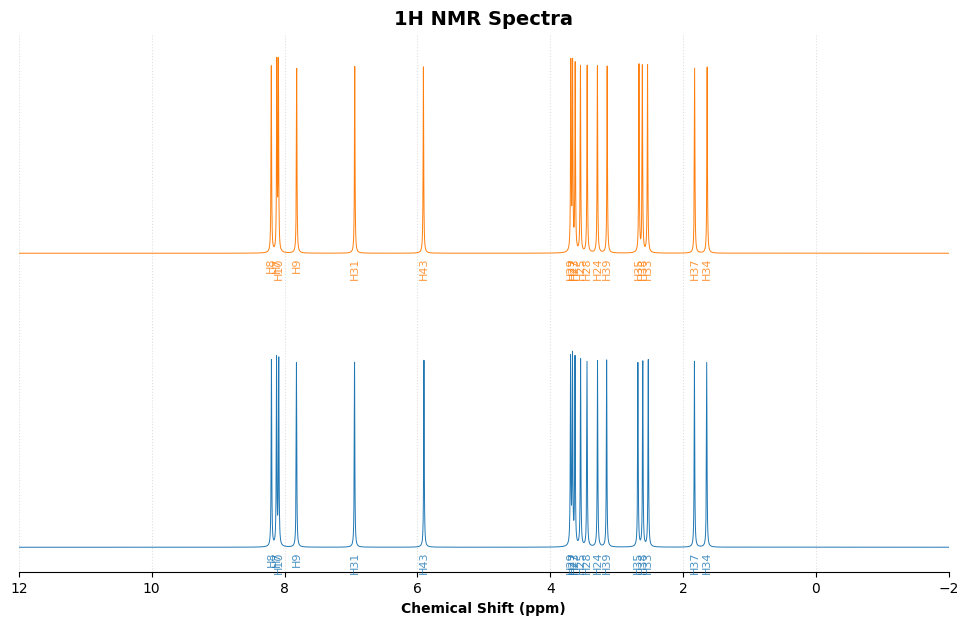

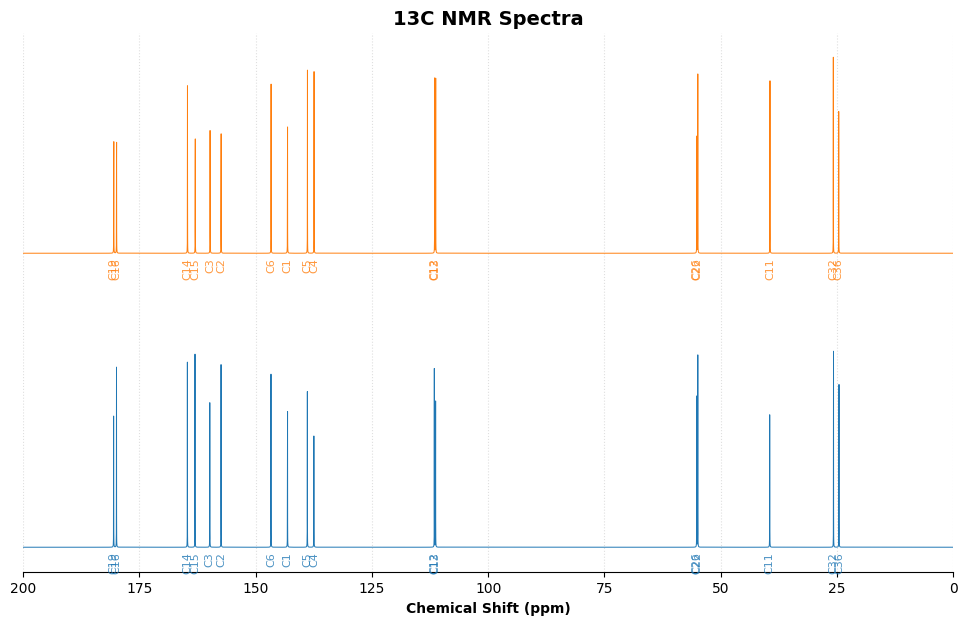

In [86]:
# we used RIJK and RIJCOSX approximations to speed up the calculations by a lot!
# Lets see the difference it makes...

nmr_data_approx = {
    "./Nifedipine_NMR/Nifedipine_GlobalMin_NMR_DMSO_ChemShifts_PBE0_pcSseg-2_RIJCOSX.out": {
        "label": "Nif (DMSO RIJCOSX)", 
        "tms": "./TMS_NMR/TMS_DMSO_PBE0_pcSseg-2_RIJCOSX_NMR.out"
    },
    "./Nifedipine_NMR/Nifedipine_GlobalMin_NMR_DMSO_ChemShifts_PBE0_pcSseg-2_RIJK.out": {
        "label": "Nif (DMSO RIJK)", 
        "tms": "./TMS_NMR/TMS_DMSO_PBE0_pcSseg-2_RIJK_NMR.out"
    }
}

plot_orca_nmr(
    file_input=nmr_data_approx, 
    nucleus='1H', 
    fwhm=0.01,        # Sharp lines
    offset=1.5,       # Vertical spacing
    linewidth=.7,    # Line width
    x_range=(-2, 12),  # Specific 1H NMR window
    export_csv=False
)

plot_orca_nmr(
    file_input=nmr_data_approx, 
    nucleus='13C', 
    fwhm=0.02,        # Sharp lines
    offset=1.5,       # Vertical spacing
    linewidth=.7,    # Line width
    x_range=(-0, 200),  # Specific 1H NMR window
    export_csv=False
)

<Axes: title={'center': '13C NMR Spectra'}, xlabel='Chemical Shift (ppm)'>

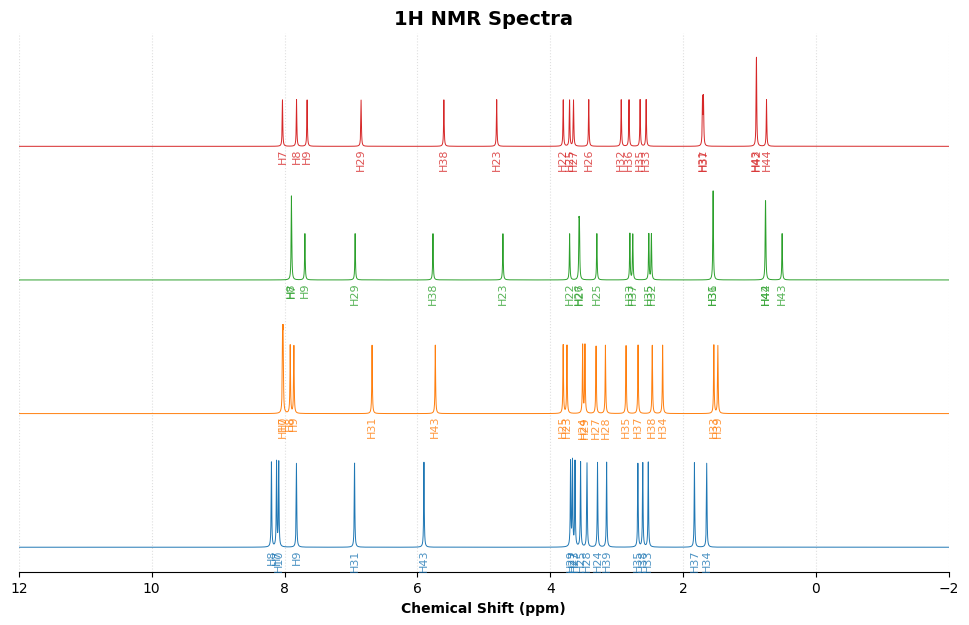

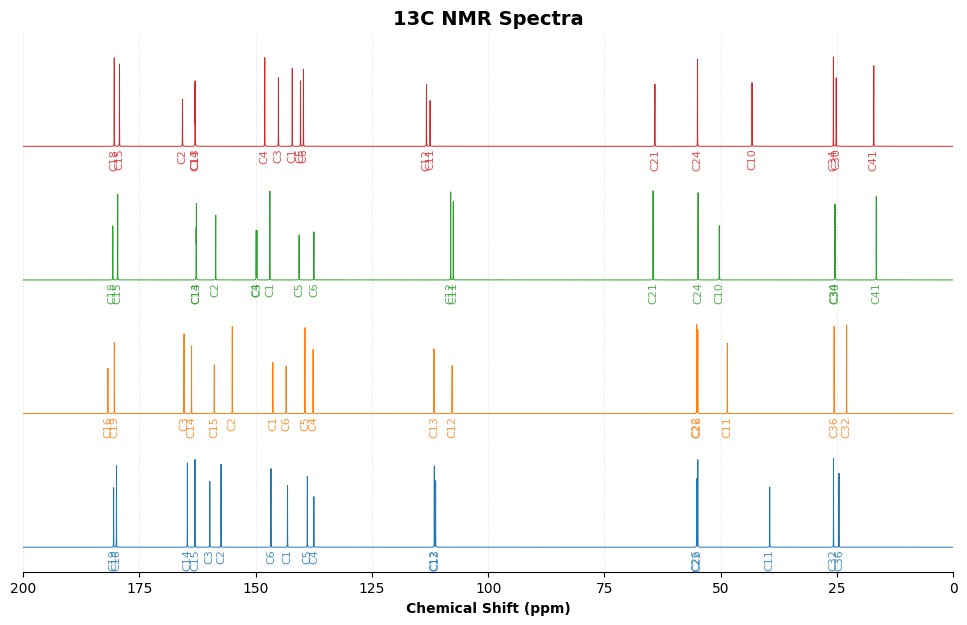

In [87]:
nmr_data_conformers_DMSO = {
    "./Nifedipine_NMR/Nifedipine_GlobalMin_NMR_DMSO_ChemShifts_PBE0_pcSseg-2_RIJCOSX.out": 
    {
        "label": "Nif C0 (DMSO)", 
        "tms": "./TMS_NMR/TMS_DMSO_PBE0_pcSseg-2_RIJCOSX_NMR.out"
    },
    "./Nifedipine_NMR/Nifedipine_Conf4_NMR_DMSO_ChemShifts_PBE0_pcSseg-2_RIJCOSX.out": 
    {
        "label": "Nif C4 (DMSO)", 
        "tms": "./TMS_NMR/TMS_DMSO_PBE0_pcSseg-2_RIJCOSX_NMR.out"
    },
    "./Felodipine_NMR/Felodipine_GlobalMin_NMR_SMD_DMSO_ChemShifts_PBE0_pcSseg-2_RIJCOSX.out": 
    {
        "label": "Fel C0 (DMSO)", 
        "tms": "./TMS_NMR/TMS_DMSO_PBE0_pcSseg-2_RIJCOSX_NMR.out"
    },
    "./Felodipine_NMR/Felodipine_Conf4_NMR_SMD_DMSO_ChemShifts_PBE0_pcSseg-2_RIJCOSX.out": 
    {
        "label": "Fel C4 (DMSO)", 
        "tms": "./TMS_NMR/TMS_DMSO_PBE0_pcSseg-2_RIJCOSX_NMR.out"
    }
}

plot_orca_nmr(
    file_input=nmr_data_conformers_DMSO, 
    nucleus='1H', 
    fwhm=0.01,        # Sharp lines
    offset=1.5,       # Vertical spacing
    linewidth=.7,    # Line width
    x_range=(-2, 12),  # Specific 1H NMR window
    export_csv=False
)

plot_orca_nmr(
    file_input=nmr_data_conformers_DMSO, 
    nucleus='13C', 
    fwhm=0.02,        # Sharp lines
    offset=1.5,       # Vertical spacing
    linewidth=.7,    # Line width
    x_range=(0, 200),  # Specific 1H NMR window
    export_csv=False
)

<Axes: title={'center': '13C NMR Spectra'}, xlabel='Chemical Shift (ppm)'>

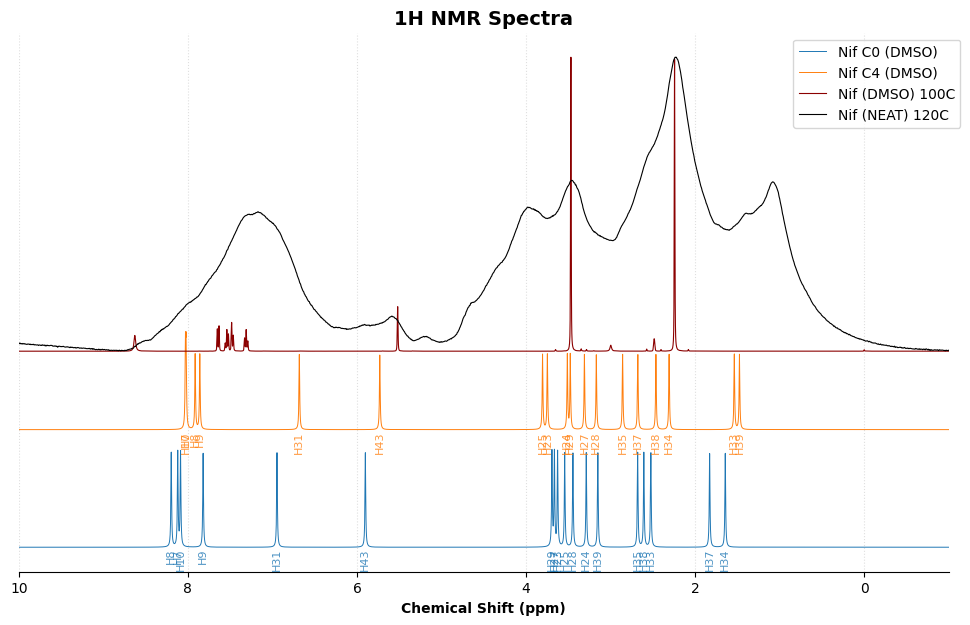

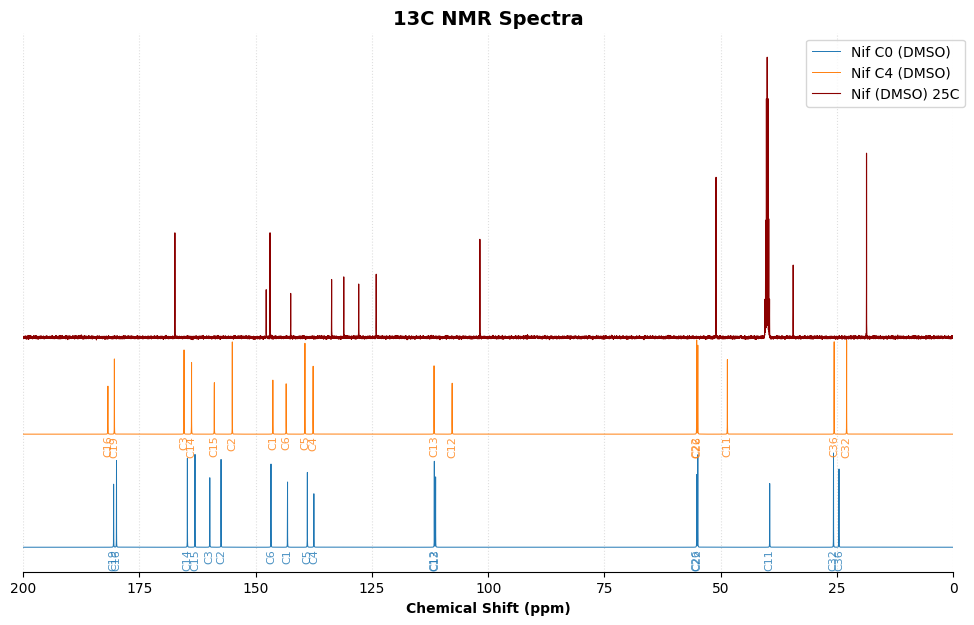

In [88]:
nmr_data_conformers_DMSO = {
    "./Nifedipine_NMR/Nifedipine_GlobalMin_NMR_DMSO_ChemShifts_PBE0_pcSseg-2_RIJCOSX.out": 
    {
        "label": "Nif C0 (DMSO)", 
        "tms": "./TMS_NMR/TMS_DMSO_PBE0_pcSseg-2_RIJCOSX_NMR.out"
    },
    "./Nifedipine_NMR/Nifedipine_Conf4_NMR_DMSO_ChemShifts_PBE0_pcSseg-2_RIJCOSX.out": 
    {
        "label": "Nif C4 (DMSO)", 
        "tms": "./TMS_NMR/TMS_DMSO_PBE0_pcSseg-2_RIJCOSX_NMR.out"
    }
}

ax_handle_1H_Nif = plot_orca_nmr(
    file_input=nmr_data_conformers_DMSO, 
    nucleus='1H', 
    fwhm=0.01,        # Sharp lines
    offset=1.2,       # Vertical spacing
    linewidth=.7,    # Line width
    x_range=(-1, 10),  # Specific 1H NMR window
    export_csv=False,
    label_voffset=0.01
)

ax_handle_13C_Nif = plot_orca_nmr(
    file_input=nmr_data_conformers_DMSO, 
    nucleus='13C', 
    fwhm=0.02,        # Sharp lines
    offset=1.2,       # Vertical spacing
    linewidth=.7,    # Line width
    x_range=(0, 200),  # Specific 1H NMR window
    export_csv=False,
    label_voffset=0.01
)

add_experimental_nmr(
    ax=ax_handle_1H_Nif, 
    filepath='./NMR_Text_Data/1H_Nif_DMSO_100C_16scans_30sD1.fid.tsv', 
    label='Nif (DMSO) 100C', 
    color='darkred',
    scale=3,
    offset=2
)
add_experimental_nmr(
    ax=ax_handle_1H_Nif, 
    filepath='./NMR_Text_Data/1H_Nif_pure_120C_16scans_3sD1.fid.tsv', 
    label='Nif (NEAT) 120C', 
    color='black',
    offset=2,
    scale=3,
    x_shift=.5,
)

add_experimental_nmr(
    ax=ax_handle_13C_Nif, 
    filepath='./NMR_Text_Data/2026_04_03_nif_dmso_fs_bruker500_zgpg30_13C_25C.tsv', 
    label='Nif (DMSO) 25C', 
    color='darkred',
    offset=2.2,
    scale=3
)

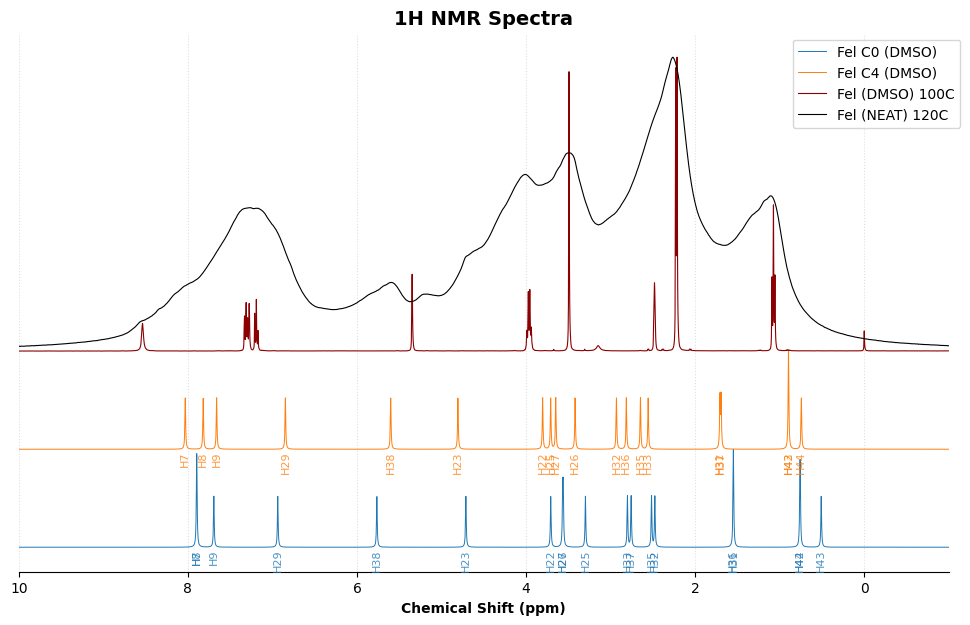

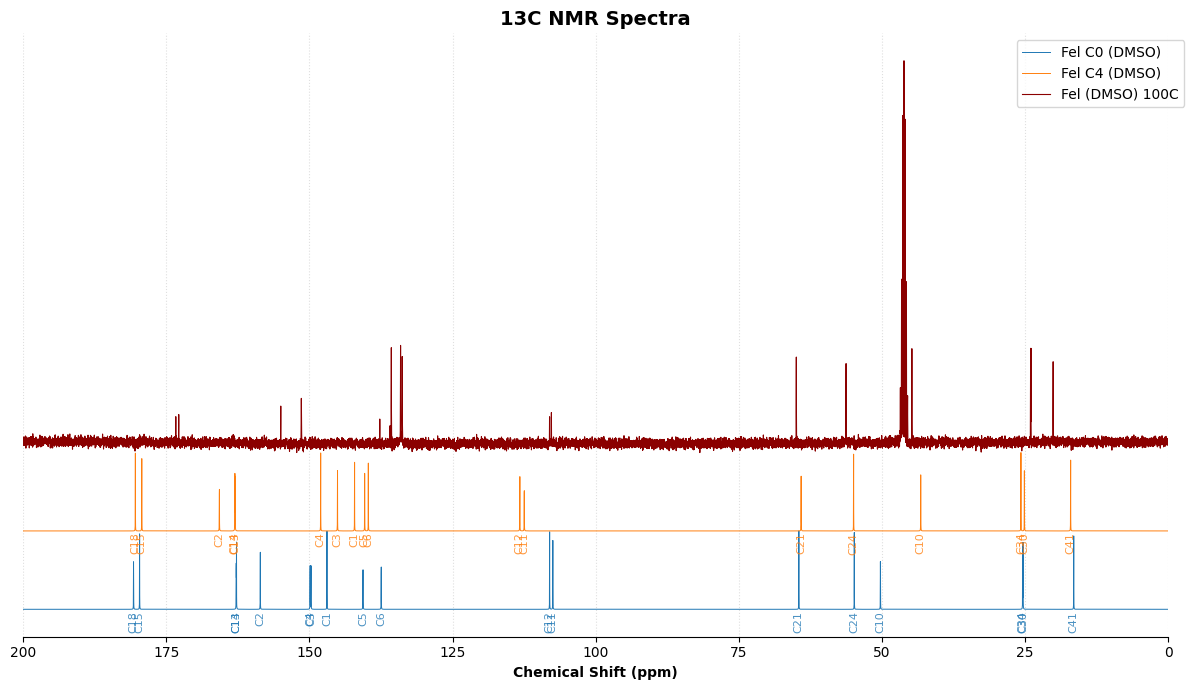

In [89]:

nmr_data_conformers_DMSO = {
    "./Felodipine_NMR/Felodipine_GlobalMin_NMR_SMD_DMSO_ChemShifts_PBE0_pcSseg-2_RIJCOSX.out": 
    {
        "label": "Fel C0 (DMSO)", 
        "tms": "./TMS_NMR/TMS_DMSO_PBE0_pcSseg-2_RIJCOSX_NMR.out"
    },
    "./Felodipine_NMR/Felodipine_Conf4_NMR_SMD_DMSO_ChemShifts_PBE0_pcSseg-2_RIJCOSX.out": 
    {
        "label": "Fel C4 (DMSO)", 
        "tms": "./TMS_NMR/TMS_DMSO_PBE0_pcSseg-2_RIJCOSX_NMR.out"
    }
    
}

ax_handle_1H_Fel = plot_orca_nmr(
    file_input=nmr_data_conformers_DMSO, 
    nucleus='1H', 
    fwhm=0.01,        # Sharp lines
    offset=1,       # Vertical spacing
    linewidth=.7,    # Line width
    x_range=(-1, 10),  # Specific 1H NMR window
    export_csv=False
)

ax_handle_13C_Fel = plot_orca_nmr(
    file_input=nmr_data_conformers_DMSO, 
    nucleus='13C', 
    fwhm=0.02,        # Sharp lines
    offset=1,       # Vertical spacing
    linewidth=.7,    # Line width
    x_range=(00, 200),  # Specific 1H NMR window
    export_csv=False
)

add_experimental_nmr(
    ax=ax_handle_1H_Fel, 
    filepath='./NMR_Text_Data/1H_Fel_DMSO_100C_16scans_30sD1.fid.tsv', 
    label='Fel (DMSO) 100C', 
    color='darkred',
    offset=2,
    scale=3
)
add_experimental_nmr(
    ax=ax_handle_1H_Fel, 
    filepath='./NMR_Text_Data/1H_Fel_Pure_100mg_InsertedAt110CFromOven_120C_16scans.fid.tsv', 
    label='Fel (NEAT) 120C', 
    color='black',
    offset=2,
    scale=3,
    x_shift=1,
)

add_experimental_nmr(
    ax=ax_handle_13C_Fel, 
    filepath='./NMR_Text_Data/13C_Fel_DMSO_100C_8192scans_1sD1.fid.tsv', 
    label='Fel (DMSO) 100C', 
    color='darkred',
    offset=2,
    scale=5
)


# 3. Finally, show the combined plot
plt.tight_layout()
plt.show()